서비스 이용 기간별 월 평균 이용량 분포

In [2]:
import numpy as np # 기본 라이브러리 불러오기
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 파일 경로들 (필요 시 경로만 수정)
path_2302_2304 = 'TPS_cancel_202302_202304_p_mt.csv'
#path_2305_2307 = 'TPS_cancel_202305_202307_p_mt.csv'
#path_2308_2310 = 'TPS_cancel_202308_202310_p_mt.csv'

# 각 파일을 기간 변수명으로 로딩
df_2302_2304 = pd.read_csv(path_2302_2304)
# df_2305_2307 = pd.read_csv(path_2305_2307)
# df_2308_2310 = pd.read_csv(path_2308_2310)

In [6]:
#결측치 싹 밀자 
# 1) 빈 문자열 / 공백 문자열을 NaN으로 통일
df_tmp = df_2302_2304.replace(r'^\s*$', np.nan, regex=True)

# 2) NaN 포함 행 전부 삭제
df_clean_2302_2304 = df_tmp.dropna().reset_index(drop=True)

# 3) 삭제 전/후 행 수 확인
print("삭제 전 행 수:", df_2302_2304.shape[0])
print("삭제 후 행 수:", df_clean_2302_2304.shape[0])
print("삭제된 행 수:", df_2302_2304.shape[0] - df_clean_2302_2304.shape[0])

삭제 전 행 수: 3156481
삭제 후 행 수: 3156474
삭제된 행 수: 7


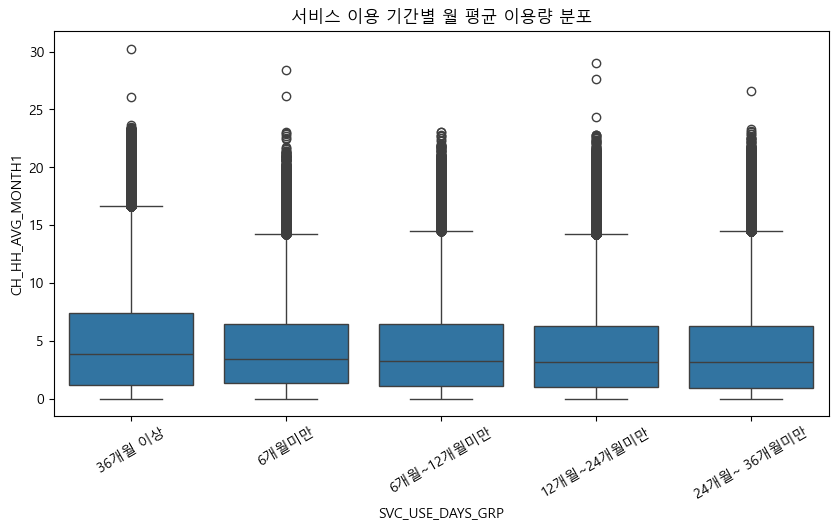

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='SVC_USE_DAYS_GRP',
    y='CH_HH_AVG_MONTH1',
    data=df_clean_2302_2304
)
plt.xticks(rotation=30)
plt.title("서비스 이용 기간별 월 평균 이용량 분포")
plt.show()


#이상치가 너무 큼 


Categorical 매칭 실패(NaN) 개수: 0
그룹별 개수:
 SVC_USE_DAYS_GRP
36개월 이상        2150844
12개월~24개월미만     337553
24개월~36개월미만     331684
6개월미만           172352
6개월~12개월미만      164041
Name: count, dtype: int64

[IQR 제거 후] 행 수: 3117431


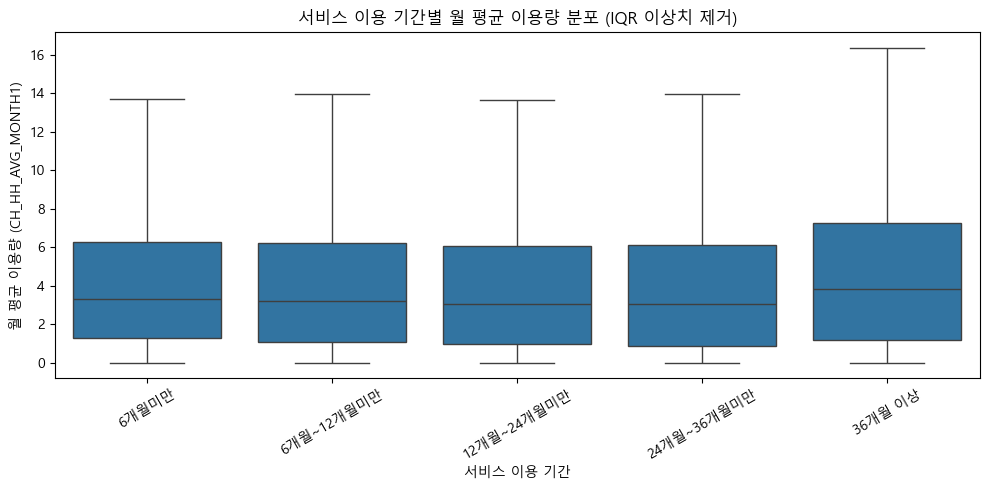

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 0) 라벨 정규화: 앞뒤 공백 제거 + '~' 주변 공백 통일
# =========================================================
df_clean_2302_2304["SVC_USE_DAYS_GRP"] = (
    df_clean_2302_2304["SVC_USE_DAYS_GRP"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s*~\s*", "~", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

# =========================================================
# 1) 기간 순서 정의
# =========================================================
order = [
    "6개월미만",
    "6개월~12개월미만",
    "12개월~24개월미만",
    "24개월~36개월미만",
    "36개월 이상"
]

# =========================================================
# 2) SVC_USE_DAYS_GRP를 순서형 범주로 변환
# =========================================================
df_clean_2302_2304["SVC_USE_DAYS_GRP"] = pd.Categorical(
    df_clean_2302_2304["SVC_USE_DAYS_GRP"],
    categories=order,
    ordered=True
)

# 매칭 실패 확인
print("Categorical 매칭 실패(NaN) 개수:",
      df_clean_2302_2304["SVC_USE_DAYS_GRP"].isna().sum())
print("그룹별 개수:\n",
      df_clean_2302_2304["SVC_USE_DAYS_GRP"].value_counts(dropna=False))

# =========================================================
# 3) IQR 기반 이상치 제거 함수 (그룹별)
# =========================================================
def remove_outliers_iqr(df, group_col, value_col):
    result = []

    for g, sub in df.groupby(group_col):
        if sub.empty:
            continue

        Q1 = sub[value_col].quantile(0.25)
        Q3 = sub[value_col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        filtered = sub[
            (sub[value_col] >= lower) &
            (sub[value_col] <= upper)
        ]
        result.append(filtered)

    return pd.concat(result, ignore_index=True)

# =========================================================
# 4) 이상치 제거 적용 (월 평균 이용량 기준)
# =========================================================
df_no_outlier_2302_2304 = remove_outliers_iqr(
    df_clean_2302_2304.dropna(
        subset=["SVC_USE_DAYS_GRP", "CH_HH_AVG_MONTH1"]
    ),
    group_col="SVC_USE_DAYS_GRP",
    value_col="CH_HH_AVG_MONTH1"
)

print("\n[IQR 제거 후] 행 수:", len(df_no_outlier_2302_2304))

# =========================================================
# 5) 박스플롯 (IQR 제거 후)
# =========================================================
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="SVC_USE_DAYS_GRP",
    y="CH_HH_AVG_MONTH1",
    data=df_no_outlier_2302_2304,
    order=order,
    showfliers=False
)

plt.xticks(rotation=30)
plt.title("서비스 이용 기간별 월 평균 이용량 분포 (IQR 이상치 제거)")
plt.xlabel("서비스 이용 기간")
plt.ylabel("월 평균 이용량 (CH_HH_AVG_MONTH1)")
plt.tight_layout()
plt.show()


In [9]:
summary_table = (
    df_no_outlier_2302_2304
    .groupby("SVC_USE_DAYS_GRP")["CH_HH_AVG_MONTH1"]
    .agg(
        count="count",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Q3=lambda x: x.quantile(0.75),
        Mean="mean"
    )
    .reset_index()
)

summary_table


,SVC_USE_DAYS_GRP,count,Q1,Median,Q3,Mean
0,6개월미만,169126,1.29,3.29,6.25,4.102335
1,6개월~12개월미만,161109,1.08,3.18,6.23,4.025251
2,12개월~24개월미만,331218,0.95,3.04,6.04,3.879933
3,24개월~36개월미만,325854,0.84,3.04,6.09,3.885041
4,36개월 이상,2130124,1.19,3.80,7.26,4.627760


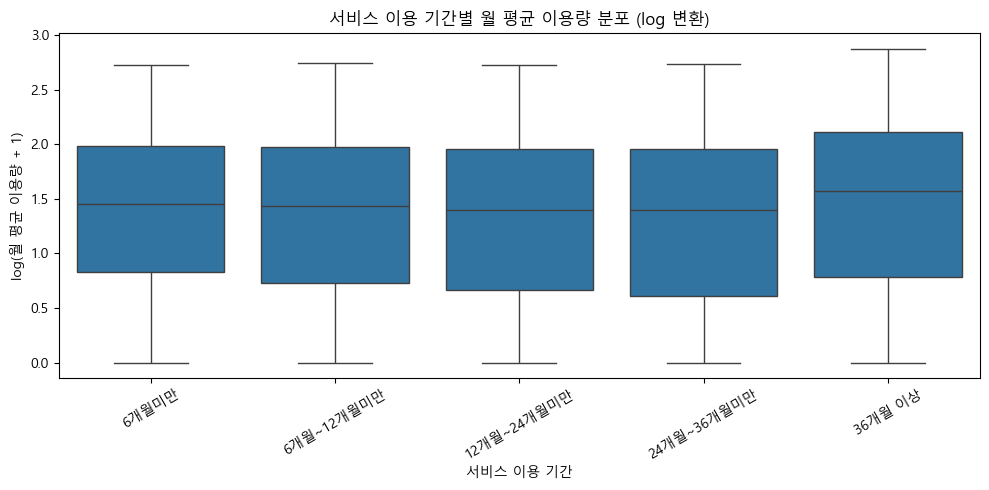

In [10]:
# 로그 변환 컬럼 추가 (0값 보정 포함)
df_no_outlier_2302_2304["log_CH_HH_AVG_MONTH1"] = np.log1p(
    df_no_outlier_2302_2304["CH_HH_AVG_MONTH1"]
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    x="SVC_USE_DAYS_GRP",
    y="log_CH_HH_AVG_MONTH1",
    data=df_no_outlier_2302_2304,
    order=order,
    showfliers=False
)

plt.xticks(rotation=30)
plt.title("서비스 이용 기간별 월 평균 이용량 분포 (log 변환)")
plt.xlabel("서비스 이용 기간")
plt.ylabel("log(월 평균 이용량 + 1)")
plt.tight_layout()
plt.show()


In [11]:
# 가설검정: 정규성 검정
from scipy.stats import shapiro

# 로그 변환된 '월 평균 이용량'에 대한 Shapiro–Wilk 검정
stat, p_value = shapiro(df_no_outlier_2302_2304["log_CH_HH_AVG_MONTH1"])

print(f"Shapiro-Wilk statistic: {stat}")
print(f"Shapiro-Wilk p-value: {p_value}")


Shapiro-Wilk statistic: 0.9257835454763167
Shapiro-Wilk p-value: 3.771553855238102e-154


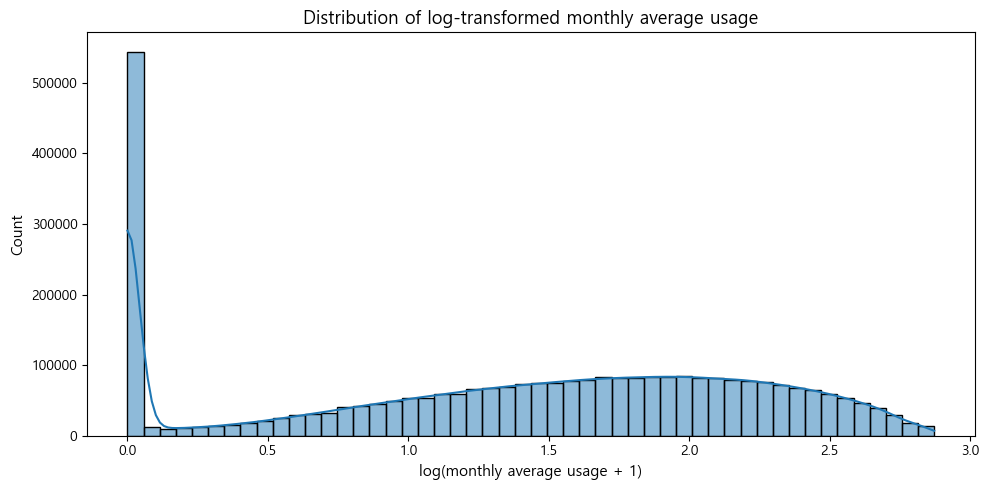

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    df_no_outlier_2302_2304["log_CH_HH_AVG_MONTH1"],
    bins=50,
    kde=True
)

plt.title("Distribution of log-transformed monthly average usage", fontsize=13)
plt.xlabel("log(monthly average usage + 1)", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.tight_layout()
plt.show()


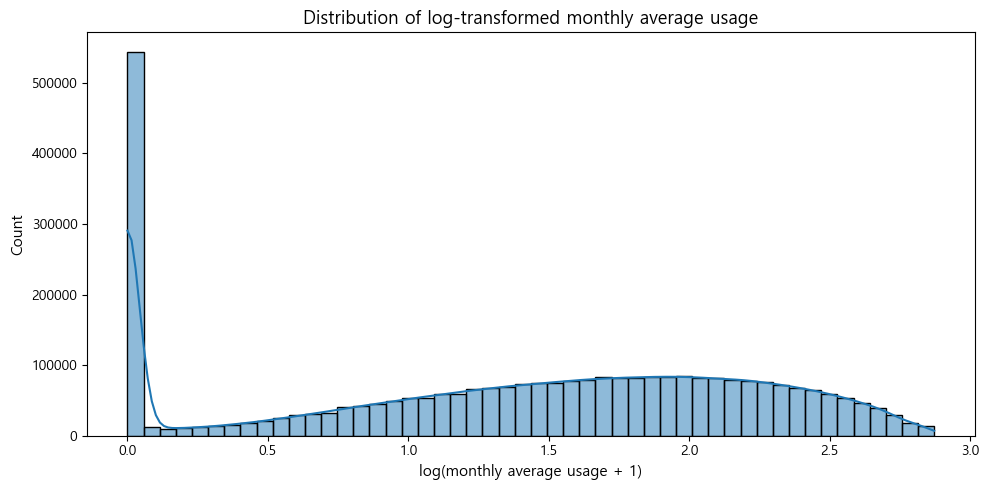

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    df_no_outlier_2302_2304["log_CH_HH_AVG_MONTH1"],
    bins=50,
    kde=True
)

plt.title("Distribution of log-transformed monthly average usage", fontsize=13)
plt.xlabel("log(monthly average usage + 1)", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.tight_layout()
plt.show()


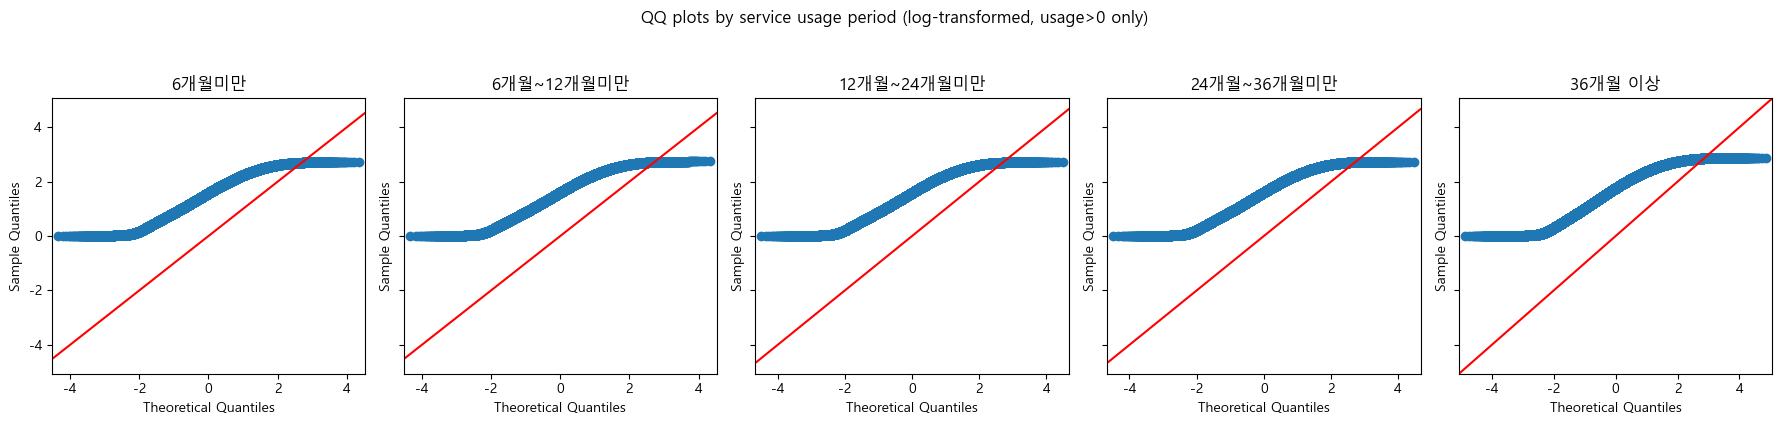

In [15]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

groups = order  

# 0 이용 고객 제외 (이용 고객 > 0만 분석 대상으로)
df_pos = df_no_outlier_2302_2304.loc[
    df_no_outlier_2302_2304["CH_HH_AVG_MONTH1"] > 0,
    ["SVC_USE_DAYS_GRP", "log_CH_HH_AVG_MONTH1"]
].dropna()

fig, axes = plt.subplots(1, len(groups), figsize=(18, 4), sharey=True)

for ax, g in zip(axes, groups):
    data_g = df_pos.loc[
        df_pos["SVC_USE_DAYS_GRP"] == g,
        "log_CH_HH_AVG_MONTH1"
    ].dropna()

    # (권장) 표본이 너무 크면 QQ-plot용 샘플링
    # 필요 없으면 아래 2줄 주석 처리해도 됨
    # if len(data_g) > 5000:
    #     data_g = data_g.sample(5000, random_state=42)

    sm.qqplot(data_g, line="45", ax=ax)
    ax.set_title(g)

plt.suptitle("QQ plots by service usage period (log-transformed, usage>0 only)", y=1.05)
plt.tight_layout()
plt.show()


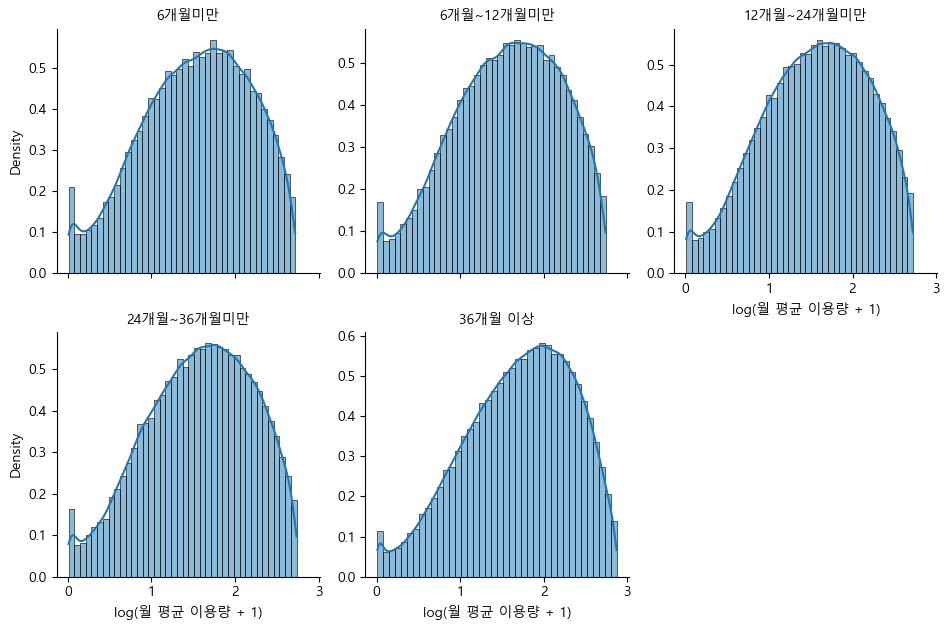

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) 분석용 데이터 복사
df_plot = df_no_outlier_2302_2304.copy()

# 2) 기간 순서 고정
df_plot["SVC_USE_DAYS_GRP"] = pd.Categorical(
    df_plot["SVC_USE_DAYS_GRP"],
    categories=order,
    ordered=True
)

# 3) (핵심) 0 이용 고객 제거
df_plot = df_plot[df_plot["CH_HH_AVG_MONTH1"] > 0].copy()

# 4) 로그 변환 (0 제거 후!)
df_plot["log_CH_HH_AVG_MONTH1"] = np.log1p(df_plot["CH_HH_AVG_MONTH1"])

# 5) 구간별 히스토그램
g = sns.FacetGrid(
    df_plot,
    col="SVC_USE_DAYS_GRP",
    col_order=order,
    col_wrap=3,
    height=3.2,
    sharex=True,
    sharey=False
)

g.map_dataframe(
    sns.histplot,
    x="log_CH_HH_AVG_MONTH1",
    bins=40,
    stat="density",
    kde=True
)

g.set_axis_labels("log(월 평균 이용량 + 1)", "Density")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 분석용 데이터
df_anova = df_no_outlier_2302_2304[[
    "SVC_USE_DAYS_GRP",
    "log_CH_HH_AVG_MONTH1"
]].dropna().copy()

# 범주형 + 순서 유지
df_anova["SVC_USE_DAYS_GRP"] = pd.Categorical(
    df_anova["SVC_USE_DAYS_GRP"],
    categories=order,
    ordered=True
)

# one-way ANOVA
model = smf.ols(
    "log_CH_HH_AVG_MONTH1 ~ C(SVC_USE_DAYS_GRP)",
    data=df_anova
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                           sum_sq         df            F  PR(>F)
C(SVC_USE_DAYS_GRP)  8.528633e+03        4.0  2944.887273     0.0
Residual             2.257080e+06  3117426.0          NaN     NaN


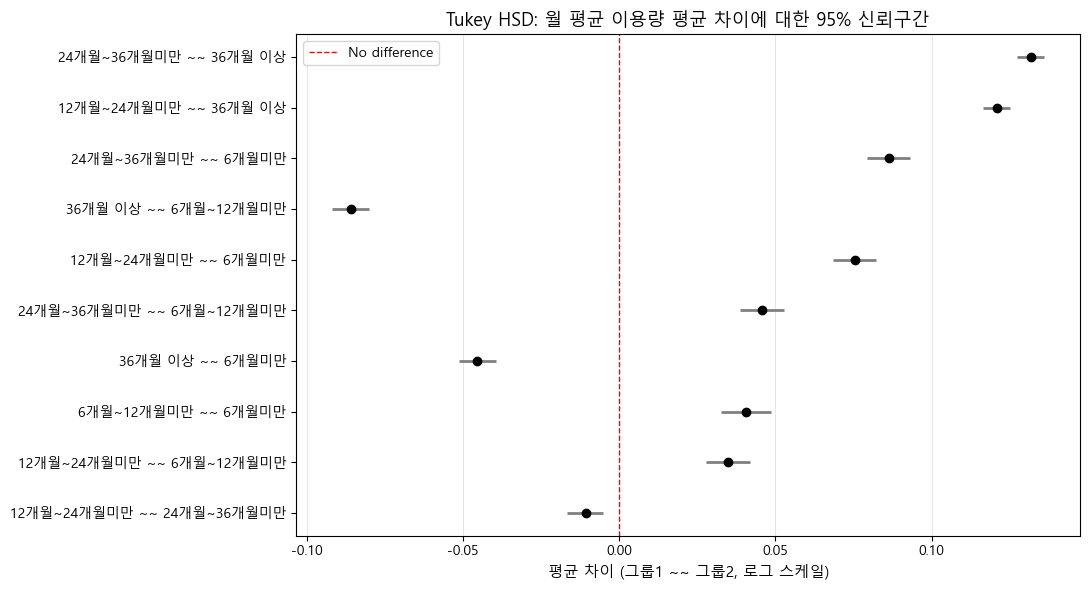

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1) Tukey HSD
tukey = pairwise_tukeyhsd(
    endog=df_anova["log_CH_HH_AVG_MONTH1"],   # ✅ 변수 수정
    groups=df_anova["SVC_USE_DAYS_GRP"],
    alpha=0.05
)

# 2) 결과 추출
rows = tukey.summary().data[1:]

labels   = [f"{r[0]} ~~ {r[1]}" for r in rows]
meandiff = np.array([float(r[2]) for r in rows])
lower    = np.array([float(r[4]) for r in rows])
upper    = np.array([float(r[5]) for r in rows])

# 3) 절댓값 기준 정렬
order_idx = np.argsort(np.abs(meandiff))

labels   = [labels[i] for i in order_idx]
meandiff = meandiff[order_idx]
lower    = lower[order_idx]
upper    = upper[order_idx]

y = np.arange(len(labels))

# 4) Plot
plt.figure(figsize=(11, 6))

plt.hlines(
    y=y,
    xmin=lower,
    xmax=upper,
    color="gray",
    linewidth=2
)

plt.scatter(
    meandiff,
    y,
    color="black",
    zorder=3
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1,
    label="No difference"
)

plt.yticks(y, labels, fontsize=10)
plt.xlabel("평균 차이 (그룹1 ~~ 그룹2, 로그 스케일)", fontsize=11)
plt.title("Tukey HSD: 월 평균 이용량 평균 차이에 대한 95% 신뢰구간", fontsize=13)

plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
from scipy.stats import ttest_ind

# 36개월 이상
group_long = df_no_outlier_2302_2304.loc[
    df_no_outlier_2302_2304["SVC_USE_DAYS_GRP"] == "36개월 이상",
    "log_CH_HH_AVG_MONTH1"
]

# 나머지 (6~36개월 + 6개월 미만)
group_others = df_no_outlier_2302_2304.loc[
    df_no_outlier_2302_2304["SVC_USE_DAYS_GRP"] != "36개월 이상",
    "log_CH_HH_AVG_MONTH1"
]

# Welch t-test
t_stat, p_value = ttest_ind(
    group_long,
    group_others,
    equal_var=False
)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")


t-statistic: 104.32759247004977
p-value: 0.0


In [24]:
# cancel_yn: '해지'/'유지' -> 1/0
df["cancel_yn"] = (
    df["cancel_yn"]
    .astype(str).str.strip()
    .map({"해지": 1, "유지": 0})
)

# 혹시 다른 값이 섞였는지 점검(정상이라면 NaN 0개여야 함)
print("변환 실패(NaN) 개수:", df["cancel_yn"].isna().sum())
print(df["cancel_yn"].value_counts(dropna=False))

# 변환 실패가 있으면 제거 or 원인 확인
df = df.dropna(subset=["cancel_yn"]).copy()
df["cancel_yn"] = df["cancel_yn"].astype(int)


변환 실패(NaN) 개수: 0
cancel_yn
0    5748387
1     509290
Name: count, dtype: int64


In [28]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

df_sha = pd.read_csv("sha_tps_cancel_202302_to_202304.csv")

need_cols = ["sha2_hash", "SVC_USE_DAYS_GRP", "cancel_yn"]
df = df_sha[need_cols].copy()

# ✅ 여기만 수정
df["cancel_yn"] = df["cancel_yn"].astype(str).str.strip().map({"해지": 1, "유지": 0})
df = df.dropna(subset=["cancel_yn"]).copy()
df["cancel_yn"] = df["cancel_yn"].astype(int)

df["grp_long"] = np.where(df["SVC_USE_DAYS_GRP"] == "36개월 이상", 1, 0)

df_cust = df.groupby("sha2_hash").agg(
    grp_long=("grp_long", "max"),
    cancel_yn=("cancel_yn", "max")
).reset_index()

ct = pd.crosstab(df_cust["grp_long"], df_cust["cancel_yn"])
ct.index = ["Others(<36m)", "Long(36m+)"]
ct.columns = ["NotCanceled(0)", "Canceled(1)"]

print(ct)

cancel_rate_long   = ct.loc["Long(36m+)", "Canceled(1)"] / ct.loc["Long(36m+)"].sum()
cancel_rate_others = ct.loc["Others(<36m)", "Canceled(1)"] / ct.loc["Others(<36m)"].sum()
print(f"\nLong(36m+):   {cancel_rate_long:.4%}")
print(f"Others(<36m): {cancel_rate_others:.4%}")
print(f"Diff (pp):    {(cancel_rate_long - cancel_rate_others)*100:.3f} %p")

chi2, p, dof, expected = chi2_contingency(ct.values)
print(f"\nchi2={chi2:.4f}, dof={dof}, p-value={p:.6g}")

count = np.array([ct.loc["Long(36m+)", "Canceled(1)"], ct.loc["Others(<36m)", "Canceled(1)"]])
nobs  = np.array([ct.loc["Long(36m+)"].sum(),          ct.loc["Others(<36m)"].sum()])
zstat, p_z = proportions_ztest(count, nobs)
print(f"\nz={zstat:.4f}, p-value={p_z:.6g}")

ci_low, ci_high = confint_proportions_2indep(
    count1=count[0], nobs1=nobs[0],
    count2=count[1], nobs2=nobs[1],
    method="wald"
)
print(f"\n95% CI (p_long - p_others): [{ci_low:.6f}, {ci_high:.6f}]")
print(f"95% CI in %p: [{ci_low*100:.3f}, {ci_high*100:.3f}]")


              NotCanceled(0)  Canceled(1)
Others(<36m)          575325        70938
Long(36m+)           1314937       114377

Long(36m+):   8.0022%
Others(<36m): 10.9766%
Diff (pp):    -2.974 %p

chi2=4841.8754, dof=1, p-value=0

z=-69.5862, p-value=0

95% CI (p_long - p_others): [-0.030627, -0.028862]
95% CI in %p: [-3.063, -2.886]


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# =========================
# 0) 로딩
# =========================
df_sha = pd.read_csv("sha_tps_cancel_202302_to_202304.csv")

need_cols = ["sha2_hash", "SVC_USE_DAYS_GRP", "cancel_yn", "CH_HH_AVG_MONTH1"]
df = df_sha[need_cols].copy()

# cancel_yn: 해지/유지 -> 1/0
df["cancel_yn"] = df["cancel_yn"].astype(str).str.strip().map({"해지": 1, "유지": 0})
df = df.dropna(subset=["cancel_yn"]).copy()
df["cancel_yn"] = df["cancel_yn"].astype(int)

# 이용량 결측 처리
df["CH_HH_AVG_MONTH1"] = pd.to_numeric(df["CH_HH_AVG_MONTH1"], errors="coerce")

# 장기 그룹
df["grp_long"] = (df["SVC_USE_DAYS_GRP"] == "36개월 이상").astype(int)


# =========================
#  해지율 비교 
# =========================
def churn_compare_all(df_in, label="0 포함 (전체)"):
    df_cust = df_in.groupby("sha2_hash").agg(
        grp_long=("grp_long", "max"),
        cancel_yn=("cancel_yn", "max")
    ).reset_index()

    ct = pd.crosstab(df_cust["grp_long"], df_cust["cancel_yn"])
    ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    rate_long   = ct.loc[1, 1] / ct.loc[1].sum()
    rate_others = ct.loc[0, 1] / ct.loc[0].sum()
    diff_pp = (rate_long - rate_others) * 100

    chi2, p, dof, exp = chi2_contingency(ct.values)

    print(f"\n[{label}]")
    print("2x2 table (grp_long x cancel_yn)")
    print(
        ct.rename(index={0: "Others(<36m)", 1: "Long(36m+)"},
                  columns={0: "NotCanceled(0)", 1: "Canceled(1)"})
    )
    print(f"Long cancel rate:   {rate_long:.4%}")
    print(f"Others cancel rate: {rate_others:.4%}")
    print(f"Diff: {diff_pp:.3f} %p")
    print(f"Chi-square p-value: {p:.6g}")

# 전체()만 실행
churn_compare_all(df)



[0 포함 (전체)]
2x2 table (grp_long x cancel_yn)
cancel_yn     NotCanceled(0)  Canceled(1)
grp_long                                 
Others(<36m)          575325        70938
Long(36m+)           1314937       114377
Long cancel rate:   8.0022%
Others cancel rate: 10.9766%
Diff: -2.974 %p
Chi-square p-value: 0
